In [8]:
pip install flask numpy scipy scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\srkkr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd

# Load the dataset
columns = [  # your full column list
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df = pd.read_csv("KDDTest+.csv", names=columns)

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()

# Show unique values for categorical columns
print("\n🧠 Unique values in categorical columns:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:10]}")  # show first 10 unique values

# Show summary stats for numerical columns
print("\n📈 Summary statistics for numerical columns:")
print(df[numerical_cols].describe())

# Optional: show value counts for label column
print("\n🚨 Attack types and frequencies:")
print(df['label'].value_counts())


🧠 Unique values in categorical columns:
protocol_type: ['tcp' 'icmp' 'udp']
service: ['private' 'ftp_data' 'eco_i' 'telnet' 'http' 'smtp' 'ftp' 'ldap' 'pop_3'
 'courier']
flag: ['REJ' 'SF' 'RSTO' 'S0' 'RSTR' 'SH' 'S3' 'S2' 'S1' 'RSTOS0']
label: ['neptune' 'normal' 'saint' 'mscan' 'guess_passwd' 'smurf' 'apache2'
 'satan' 'buffer_overflow' 'back']

📈 Summary statistics for numerical columns:
           duration     src_bytes     dst_bytes          land  wrong_fragment  \
count  22543.000000  2.254300e+04  2.254300e+04  22543.000000    22543.000000   
mean     218.868784  1.039591e+04  2.056110e+03      0.000311        0.008428   
std     1407.207069  4.727969e+05  2.121976e+04      0.017619        0.142602   
min        0.000000  0.000000e+00  0.000000e+00      0.000000        0.000000   
25%        0.000000  0.000000e+00  0.000000e+00      0.000000        0.000000   
50%        0.000000  5.400000e+01  4.600000e+01      0.000000        0.000000   
75%        0.000000  2.870000e+02  6.0

In [1]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import joblib

# 📂 Load dataset
df = pd.read_csv('KDDTest+.csv', header=None)

# 🏷️ Assign column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df.columns = columns

# 🔢 Manual encoding maps
protocol_map = {'udp': 0, 'tcp': 1, 'icmp': 2}
service_map = {
    'private': 0, 'ftp_data': 1, 'eco_i': 2, 'telnet': 3, 'http': 4,
    'smtp': 5, 'ftp': 6, 'ldap': 7, 'pop_3': 8, 'courier': 9
}
flag_map = {
    'REJ': 0, 'SF': 1, 'RSTO': 2, 'S0': 3, 'RSTR': 4,
    'SH': 5, 'S3': 6, 'S2': 7, 'S1': 8, 'RSTOS0': 9
}

# 🔄 Apply manual encoding
df['protocol_type'] = df['protocol_type'].map(protocol_map)
df['service'] = df['service'].map(service_map)
df['flag'] = df['flag'].map(flag_map)

# 🔄 Encode label using LabelEncoder (for multi-class classification)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# 🎯 Use all 41 features except label and difficulty_level
X = df.drop(columns=['label', 'difficulty_level'])
y = df['label']

# 🚫 Remove classes with <2 samples before splitting
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]
# 🧼 Fill NaNs with a default value (e.g., -1)
X = X.fillna(-1)

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ⚖️ Apply SMOTE safely
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 🌲 Train Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_resampled, y_resampled)

# 📈 Evaluate model
y_pred_rf = rf_model.predict(X_test)
print("✅ Model trained with manual encoding and SMOTE")
print("🔍 Accuracy:", accuracy_score(y_test, y_pred_rf))
print("📊 Classification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

# 💾 Save model and label encoder
joblib.dump(rf_model, 'rf_model_full.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

✅ Model trained with manual encoding and SMOTE
🔍 Accuracy: 0.980261698824573
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       1.00      1.00      1.00        72
           2       1.00      0.50      0.67         4
           3       0.00      0.00      0.00         1
           4       0.98      1.00      0.99       246
           5       1.00      0.93      0.96        27
           7       1.00      1.00      1.00        28
           8       1.00      1.00      1.00         1
          10       1.00      0.98      0.99        59
          11       0.98      0.99      0.99       199
          12       0.00      0.00      0.00         4
          13       0.33      0.33      0.33         3
          14       1.00      1.00      1.00       932
          15       1.00      1.00      1.00        15
          16       0.98      0.98      0.98      1942
          17       0.00      0.0

['label_encoder.pkl']

In [4]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import joblib

# 📂 Load dataset
df = pd.read_csv('KDDTest+.csv', header=None)

# 🏷️ Assign column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df.columns = columns

# 🔄 Encode categorical columns
encoder = LabelEncoder()
for col in ['protocol_type', 'service', 'flag', 'label']:
    df[col] = encoder.fit_transform(df[col])

# 🎯 Use all 41 features except label and difficulty_level
X = df.drop(columns=['label', 'difficulty_level'])
y = df['label']

# 🚫 Remove classes with <2 samples before splitting
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ⚖️ Apply SMOTE safely
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 🌲 Train Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_resampled, y_resampled)

# 📈 Evaluate model
y_pred_rf = rf_model.predict(X_test)
print("✅ Model trained with all 41 features")
print("🔍 Accuracy:", accuracy_score(y_test, y_pred_rf))
print("📊 Classification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

# 💾 Save model
joblib.dump(rf_model, 'rf_model_full.pkl')


✅ Model trained with all 41 features
🔍 Accuracy: 0.9804834774894655
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       1.00      1.00      1.00        72
           2       0.75      0.75      0.75         4
           3       0.00      0.00      0.00         1
           4       0.98      1.00      0.99       246
           5       0.96      0.93      0.94        27
           7       0.97      1.00      0.98        28
           8       1.00      1.00      1.00         1
          10       1.00      0.98      0.99        59
          11       0.98      0.99      0.99       199
          12       0.00      0.00      0.00         4
          13       0.67      0.67      0.67         3
          14       1.00      1.00      1.00       932
          15       1.00      1.00      1.00        15
          16       0.99      0.98      0.98      1942
          19       1.00      1.00      1.

['rf_model_full.pkl']

In [2]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib
from xgboost import XGBClassifier

# 📂 Load dataset
df = pd.read_csv('KDDTest+.csv', header=None)

# 🏷️ Assign column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df.columns = columns

# 🔢 Manual encoding maps
protocol_map = {'udp': 0, 'tcp': 1, 'icmp': 2}
service_map = {
    'private': 0, 'ftp_data': 1, 'eco_i': 2, 'telnet': 3, 'http': 4,
    'smtp': 5, 'ftp': 6, 'ldap': 7, 'pop_3': 8, 'courier': 9
}
flag_map = {
    'REJ': 0, 'SF': 1, 'RSTO': 2, 'S0': 3, 'RSTR': 4,
    'SH': 5, 'S3': 6, 'S2': 7, 'S1': 8, 'RSTOS0': 9
}

# 🔄 Apply manual encoding
df['protocol_type'] = df['protocol_type'].map(protocol_map)
df['service'] = df['service'].map(service_map)
df['flag'] = df['flag'].map(flag_map)

# 🔄 Encode label initially
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# 🎯 Use all 41 features except label and difficulty_level
X = df.drop(columns=['label', 'difficulty_level'])
y = df['label']

# 🚫 Remove classes with <2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# 🔄 Re-encode labels to make them contiguous
final_label_encoder = LabelEncoder()
y = final_label_encoder.fit_transform(y)

# 🧼 Fill NaNs
X = X.fillna(-1)

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ⚖️ Apply SMOTE
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 🚀 Train XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_resampled)),  # contiguous classes
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_resampled, y_resampled)

# 📈 Evaluate model
y_pred_xgb = xgb_model.predict(X_test)
print("✅ Model trained with XGBoost")
print("🔍 Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("📊 Classification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))

# 💾 Save model and encoder
joblib.dump(xgb_model, 'xgb_model_full.pkl')
joblib.dump(final_label_encoder, 'label_encoder.pkl')

# 🔎 Example: Decode predictions back to original labels
decoded_labels = final_label_encoder.inverse_transform(y_pred_xgb)
print("🔖 Sample decoded predictions:", decoded_labels[:10])


C:\Users\srkkr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:27:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model trained with XGBoost
🔍 Accuracy: 0.9818141494788202
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       1.00      1.00      1.00        72
           2       0.33      0.25      0.29         4
           3       0.00      0.00      0.00         1
           4       0.98      1.00      0.99       246
           5       0.96      0.93      0.94        27
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00        59
          10       0.98      0.99      0.99       199
          11       0.33      0.50      0.40         4
          12       0.50      0.33      0.40         3
          13       1.00      1.00      1.00       932
          14       1.00      1.00      1.00        15
          15       0.99      0.98      0.99      1942
          18       0.88      0.88      0.88      

In [3]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib

# Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# 📂 Load dataset
df = pd.read_csv('KDDTest+.csv', header=None)

# 🏷️ Assign column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df.columns = columns

# 🔢 Manual encoding maps
protocol_map = {'udp': 0, 'tcp': 1, 'icmp': 2}
service_map = {
    'private': 0, 'ftp_data': 1, 'eco_i': 2, 'telnet': 3, 'http': 4,
    'smtp': 5, 'ftp': 6, 'ldap': 7, 'pop_3': 8, 'courier': 9
}
flag_map = {
    'REJ': 0, 'SF': 1, 'RSTO': 2, 'S0': 3, 'RSTR': 4,
    'SH': 5, 'S3': 6, 'S2': 7, 'S1': 8, 'RSTOS0': 9
}

# 🔄 Apply manual encoding
df['protocol_type'] = df['protocol_type'].map(protocol_map)
df['service'] = df['service'].map(service_map)
df['flag'] = df['flag'].map(flag_map)

# 🔄 Encode label initially
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# 🎯 Use all 41 features except label and difficulty_level
X = df.drop(columns=['label', 'difficulty_level'])
y = df['label']

# 🚫 Remove classes with <2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# 🔄 Re-encode labels to make them contiguous
final_label_encoder = LabelEncoder()
y = final_label_encoder.fit_transform(y)

# 🧼 Fill NaNs
X = X.fillna(-1)

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ⚖️ Apply SMOTE
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 🌲 Random Forest
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    random_state=42
)

# 🚀 XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_resampled)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# 🤝 Combine with Voting Ensemble
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    voting='soft'  # soft = probability averaging, better than hard voting
)

# 🏋️ Train ensemble
ensemble_model.fit(X_resampled, y_resampled)

# 📈 Evaluate
y_pred_ensemble = ensemble_model.predict(X_test)
print("✅ Model trained with Random Forest + XGBoost Ensemble")
print("🔍 Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("📊 Classification Report:\n", classification_report(y_test, y_pred_ensemble, zero_division=0))

# 💾 Save model and encoder
joblib.dump(ensemble_model, 'ensemble_rf_xgb.pkl')
joblib.dump(final_label_encoder, 'label_encoder.pkl')

# 🔎 Example: Decode predictions back to original labels
decoded_labels = final_label_encoder.inverse_transform(y_pred_ensemble)
print("🔖 Sample decoded predictions:", decoded_labels[:10])


C:\Users\srkkr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:38:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model trained with Random Forest + XGBoost Ensemble
🔍 Accuracy: 0.982257706808605
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       1.00      1.00      1.00        72
           2       0.33      0.25      0.29         4
           3       0.00      0.00      0.00         1
           4       0.98      1.00      0.99       246
           5       1.00      0.93      0.96        27
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00        59
          10       0.98      0.99      0.99       199
          11       0.33      0.25      0.29         4
          12       0.33      0.33      0.33         3
          13       1.00      1.00      1.00       932
          14       1.00      1.00      1.00        15
          15       0.99      0.98      0.99      1942
          18       0.89  

In [5]:
pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\srkkr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib

# Models
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 📂 Load dataset
df = pd.read_csv('KDDTest+.csv', header=None)

# 🏷️ Assign column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df.columns = columns

# 🔢 Manual encoding maps
protocol_map = {'udp': 0, 'tcp': 1, 'icmp': 2}
service_map = {
    'private': 0, 'ftp_data': 1, 'eco_i': 2, 'telnet': 3, 'http': 4,
    'smtp': 5, 'ftp': 6, 'ldap': 7, 'pop_3': 8, 'courier': 9
}
flag_map = {
    'REJ': 0, 'SF': 1, 'RSTO': 2, 'S0': 3, 'RSTR': 4,
    'SH': 5, 'S3': 6, 'S2': 7, 'S1': 8, 'RSTOS0': 9
}

# 🔄 Apply manual encoding
df['protocol_type'] = df['protocol_type'].map(protocol_map)
df['service'] = df['service'].map(service_map)
df['flag'] = df['flag'].map(flag_map)

# 🔄 Encode label initially
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# 🎯 Use all 41 features except label and difficulty_level
X = df.drop(columns=['label', 'difficulty_level'])
y = df['label']

# 🚫 Remove classes with <2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# 🔄 Re-encode labels to make them contiguous
final_label_encoder = LabelEncoder()
y = final_label_encoder.fit_transform(y)

# 🧼 Fill NaNs
X = X.fillna(-1)

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ⚖️ Apply SMOTE
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 🌲 Random Forest
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    random_state=42
)

# 🚀 XGBoost (cleaned up, no use_label_encoder)
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_resampled)),
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    verbosity=0   # suppress logs
)

# ⚡ LightGBM (quiet mode)
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y_resampled)),
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=-1    # suppress logs
)

# 🤝 Meta-model (Logistic Regression)
meta_model = LogisticRegression(max_iter=1000)

# 🏗️ Stacking Ensemble
stack_model = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model), ('lgb', lgb_model)],
    final_estimator=meta_model,
    stack_method='predict_proba'
)

# 🏋️ Train stacking ensemble
stack_model.fit(X_resampled, y_resampled)

# 📈 Evaluate
y_pred_stack = stack_model.predict(X_test)
print("✅ Model trained with Stacking Ensemble (RF + XGB + LGBM)")
print("🔍 Accuracy:", accuracy_score(y_test, y_pred_stack))
print("📊 Classification Report:\n", classification_report(y_test, y_pred_stack, zero_division=0))

# 💾 Save model and encoder
joblib.dump(stack_model, 'stacking_rf_xgb_lgb.pkl')
joblib.dump(final_label_encoder, 'label_encoder.pkl')

# 🔎 Example: Decode predictions back to original labels
decoded_labels = final_label_encoder.inverse_transform(y_pred_stack)
print("🔖 Sample decoded predictions:", decoded_labels[:10])

✅ Model trained with Stacking Ensemble (RF + XGB + LGBM)
🔍 Accuracy: 0.9820359281437125
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       1.00      1.00      1.00        72
           2       0.33      0.25      0.29         4
           3       0.00      0.00      0.00         1
           4       0.98      1.00      0.99       246
           5       1.00      0.93      0.96        27
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00        59
          10       0.98      0.99      0.98       199
          11       0.67      0.50      0.57         4
          12       0.33      0.33      0.33         3
          13       1.00      1.00      1.00       932
          14       1.00      1.00      1.00        15
          15       0.99      0.98      0.98      1942
          18       0.

In [9]:
pip install optuna

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 670.4 kB/s eta 0:00:03
   -------------- ------------------------- 0.8/2.1 MB 882.6 kB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 1.1 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\srkkr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib

# Models
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 📂 Load dataset
df = pd.read_csv('KDDTest+.csv', header=None)

# 🏷️ Assign column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]
df.columns = columns

# 🔢 Manual encoding maps
protocol_map = {'udp': 0, 'tcp': 1, 'icmp': 2}
service_map = {
    'private': 0, 'ftp_data': 1, 'eco_i': 2, 'telnet': 3, 'http': 4,
    'smtp': 5, 'ftp': 6, 'ldap': 7, 'pop_3': 8, 'courier': 9
}
flag_map = {
    'REJ': 0, 'SF': 1, 'RSTO': 2, 'S0': 3, 'RSTR': 4,
    'SH': 5, 'S3': 6, 'S2': 7, 'S1': 8, 'RSTOS0': 9
}

# 🔄 Apply manual encoding
df['protocol_type'] = df['protocol_type'].map(protocol_map)
df['service'] = df['service'].map(service_map)
df['flag'] = df['flag'].map(flag_map)

# 🔄 Encode label initially
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# 🎯 Use all 41 features except label and difficulty_level
X = df.drop(columns=['label', 'difficulty_level'])
y = df['label']

# 🚫 Remove classes with <2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# 🔄 Re-encode labels to make them contiguous
final_label_encoder = LabelEncoder()
y = final_label_encoder.fit_transform(y)

# 🧼 Fill NaNs
X = X.fillna(-1)

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ⚖️ Apply SMOTE
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 🌲 Tuned Random Forest
rf_model = RandomForestClassifier(
    n_estimators=89,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# 🚀 Tuned XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_resampled)),
    eval_metric='mlogloss',
    n_estimators=176,
    learning_rate=0.0945,
    max_depth=8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

# ⚡ Tuned LightGBM
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y_resampled)),
    n_estimators=214,
    learning_rate=0.1634,
    max_depth=5,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# 🤝 Meta-model
meta_model = LogisticRegression(max_iter=500, n_jobs=-1)

# 🏗️ Stacking Ensemble
stack_model = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model), ('lgb', lgb_model)],
    final_estimator=meta_model,
    stack_method='predict_proba',
    n_jobs=-1
)

# 🏋️ Train stacking ensemble
stack_model.fit(X_resampled, y_resampled)

# 📈 Evaluate
y_pred_stack = stack_model.predict(X_test)
print("✅ Tuned Stacking Ensemble (RF + XGB + LGBM)")
print("🔍 Accuracy:", accuracy_score(y_test, y_pred_stack))
print("📊 Classification Report:\n", classification_report(y_test, y_pred_stack, zero_division=0))

# 💾 Save model and encoder
joblib.dump(stack_model, 'stacking_rf_xgb_lgb_tuned.pkl')
joblib.dump(final_label_encoder, 'label_encoder.pkl')

# 🔎 Example: Decode predictions back to original labels
decoded_labels = final_label_encoder.inverse_transform(y_pred_stack)
print("🔖 Sample decoded predictions:", decoded_labels[:10])


C:\Users\srkkr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✅ Tuned Stacking Ensemble (RF + XGB + LGBM)
🔍 Accuracy: 0.9824794854734975
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       1.00      1.00      1.00        72
           2       0.33      0.25      0.29         4
           3       0.00      0.00      0.00         1
           4       0.98      1.00      0.99       246
           5       1.00      0.93      0.96        27
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00        59
          10       0.98      0.99      0.99       199
          11       0.33      0.25      0.29         4
          12       0.33      0.33      0.33         3
          13       1.00      1.00      1.00       932
          14       1.00      1.00      1.00        15
          15       0.99      0.98      0.99      1942
          18       0.89      1.00 

In [ ]:
!pip install matplotlib seaborn

In [10]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\srkkr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [36]:
import sys
!{sys.executable} -m pip install matplotlib seaborn --upgrade --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.1 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.9 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 2.7 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.8 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 3.0 MB/s eta 0:00:02
   ---------------------------- ---------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.41.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\srkkr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


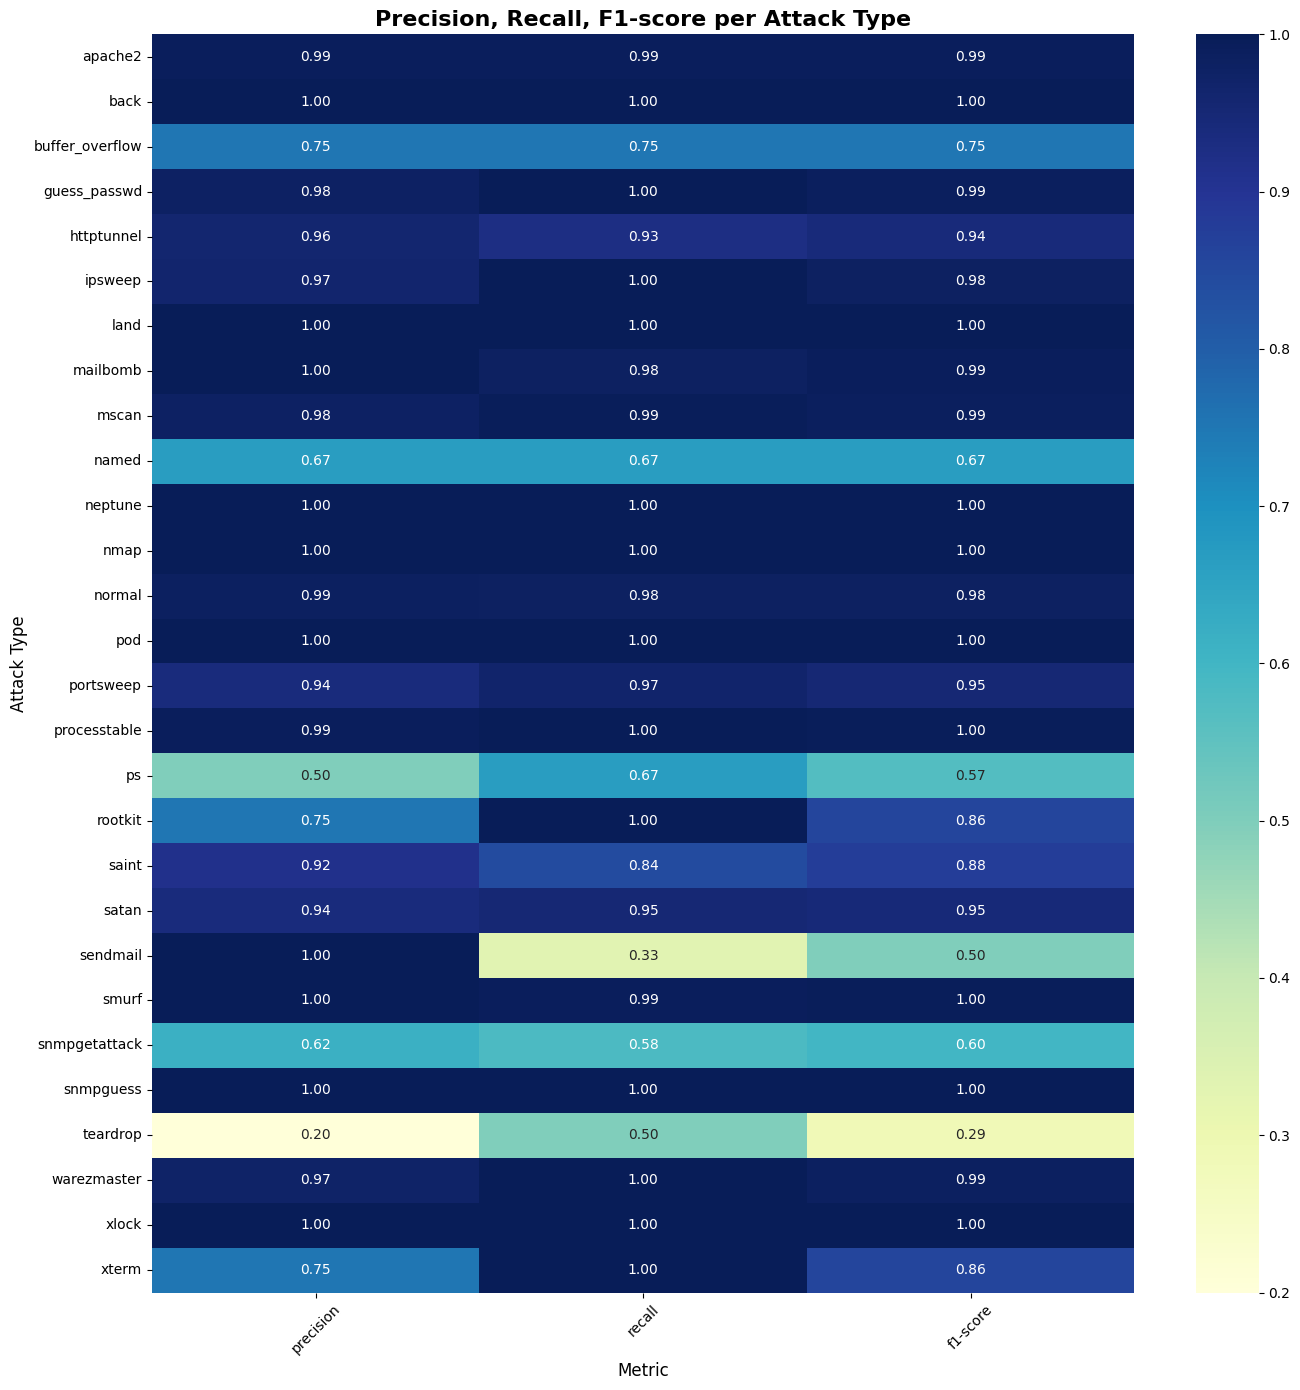

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Generate classification report
report_dict = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

# Filter out rows with all-zero metrics
filtered_df = report_df.iloc[:-3, :3]  # Remove 'accuracy', 'macro avg', 'weighted avg'
filtered_df = filtered_df[(filtered_df != 0).any(axis=1)]  # Keep rows with any non-zero metric

# Get readable attack names for filtered rows
filtered_labels = filtered_df.index.tolist()
attack_names = encoder.inverse_transform([int(label) for label in filtered_labels])

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, len(attack_names) * 0.5))
sns.heatmap(filtered_df, annot=True, fmt=".2f", cmap="YlGnBu", yticklabels=attack_names, ax=ax)

ax.set_title("Precision, Recall, F1-score per Attack Type", fontsize=16, fontweight='bold')
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Attack Type", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

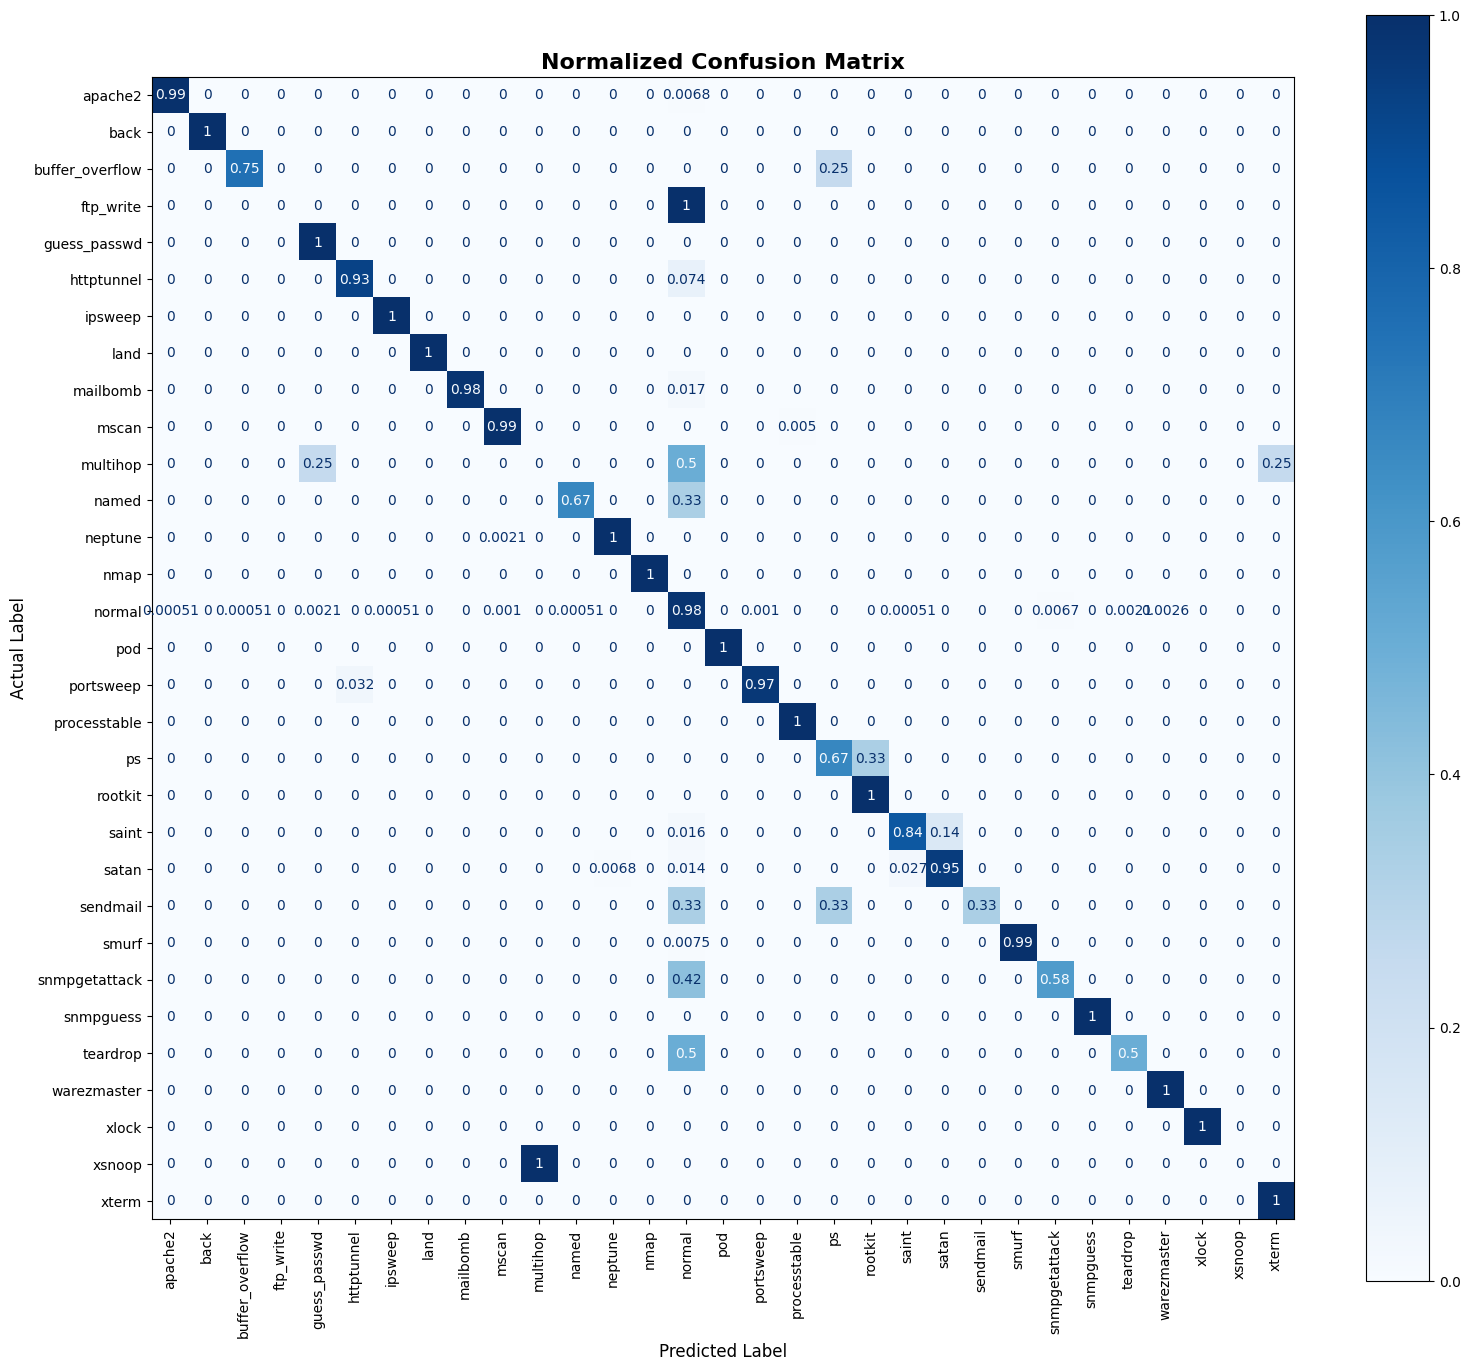

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Normalize confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, normalize='true')

# Get only the labels present in y_test
unique_labels = sorted(np.unique(y_test))
attack_names = encoder.inverse_transform(unique_labels)

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_names)
disp.plot(ax=ax, cmap='Blues')
plt.xticks(rotation=90)

plt.title("Normalized Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()